In [1]:
import json 
import os
import matplotlib.pyplot as plt
import shutil

In [2]:
versions = [
    (152, 'Pion'),
    (148, 'Ppeptide'),
    (158, 'PDNA'),
    (161, 'PRNA'),
    (149, 'PP'),
    (159, 'PL'),
    (169, 'RNAL'),
    (105, 'CSD')
]

In [4]:
checkpoint_dir = "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/pretrain/models/InteractNN-torsion/"
def get_all_checkpoints(version):
    topk_map = os.path.join(checkpoint_dir, f"version_{version}", "checkpoint", "topk_map.txt")
    with open(topk_map, "r") as f:
        best_line = f.readline()
    best_loss, best_epoch = best_line.strip().split(": ")
    best_loss = float(best_loss)

    args_file = os.path.join(checkpoint_dir, f"version_{version}", "args.json")
    args = json.load(open(args_file, "r"))
    pretrain_ckpt = args.get("pretrain_ckpt", None)

    if not pretrain_ckpt:
        return [(best_loss, best_epoch)]

    prev_version = os.path.basename(os.path.dirname(os.path.dirname(pretrain_ckpt))).replace("version_", "")
    
    return sorted(get_all_checkpoints(prev_version) + [(best_loss, best_epoch)])

In [33]:
dest_dir = "/n/holylabs/LABS/mzitnik_lab/Users/afang/ATOMICA/checkpoints/leave_one_modality_out"

for version, modality in versions:
    results = get_all_checkpoints(version)
    best_epoch = results[0][1]

    version_dir = os.path.dirname(os.path.dirname(best_epoch))

    args_json = os.path.join(version_dir, "args.json")
    training_config = os.path.join(version_dir, "train_config.json")
    config_json = os.path.join(os.path.dirname(best_epoch), "config.json")

    os.makedirs(os.path.join(dest_dir, modality), exist_ok=True)
    shutil.copy(args_json, os.path.join(dest_dir, modality, "args.json"))
    shutil.copy(training_config, os.path.join(dest_dir, modality, "train_config.json"))
    shutil.copy(config_json, os.path.join(dest_dir, modality, "config.json"))
    shutil.copy(best_epoch, os.path.join(dest_dir, modality, os.path.basename(best_epoch)))
    shutil.copy(best_epoch, os.path.join(dest_dir, modality, os.path.basename(best_epoch).replace(".ckpt", ".pt")))


Pion 4.242575342535115 /n/netscratch/mzitnik_lab/Lab/afang/InteractNN/pretrain/models/InteractNN-torsion/version_146/checkpoint/epoch104_step1132219.ckpt
Ppeptide 4.087525358777454 /n/netscratch/mzitnik_lab/Lab/afang/InteractNN/pretrain/models/InteractNN-torsion/version_148/checkpoint/epoch106_step1162711.ckpt


PDNA 4.174198852442101 /n/netscratch/mzitnik_lab/Lab/afang/InteractNN/pretrain/models/InteractNN-torsion/version_136/checkpoint/epoch112_step1197281.ckpt
PRNA 4.177163224326757 /n/netscratch/mzitnik_lab/Lab/afang/InteractNN/pretrain/models/InteractNN-torsion/version_144/checkpoint/epoch108_step1174437.ckpt
PP 4.154283111000061 /n/netscratch/mzitnik_lab/Lab/afang/InteractNN/pretrain/models/InteractNN-torsion/version_134/checkpoint/epoch92_step795275.ckpt
PL 4.085234378080641 /n/netscratch/mzitnik_lab/Lab/afang/InteractNN/pretrain/models/InteractNN-torsion/version_159/checkpoint/epoch130_step1199353.ckpt
RNAL 4.15614440403521 /n/netscratch/mzitnik_lab/Lab/afang/InteractNN/pretrain/models/InteractNN-torsion/version_169/checkpoint/epoch106_step1141258.ckpt
CSD 3.869920222024954 /n/netscratch/mzitnik_lab/Lab/afang/InteractNN/pretrain/models/InteractNN-torsion/version_105/checkpoint/epoch181_step782186.ckpt


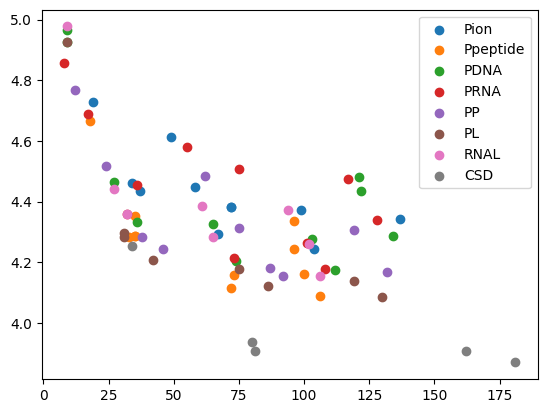

In [5]:
for version, modality in versions:
    results = get_all_checkpoints(version)
    print(modality, results[0][0], results[0][1])
    x = []
    y = []
    for loss, ckpt_path in results:
        y.append(loss)
        epoch = os.path.basename(ckpt_path).split("_")[0].replace("epoch", "")
        x.append(int(epoch))
    plt.scatter(x, y, label=modality)
plt.legend()
plt.show()
